<!--- sf-header --->
<table align="left">
<tr>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fstatmike%2Fscale-forecasting%2Fmain%2Fnotebooks%2F00_model_playground.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Colab Enterprise logo">
      <br>Run in<br>Colab Enterprise
    </a>
  </td>
</tr>
</table>
<br clear="left"/>

> **Run in Colab Enterprise:** click the badge to import this notebook, pick a runtime, and
> **Run all**. The Terraform-deployed templates already carry the `SF_*` run identity in their env,
> so there's no environment cell to fill in. Runs on the **`sf-main`** runtime template (Python 3.11) — or fully locally with just a clone; this notebook needs no cloud at all. See
> [`docs/notebook_runtimes.md`](https://github.com/statmike/scale-forecasting/blob/main/docs/notebook_runtimes.md)
> for the per-notebook template mapping and the headless acceptance harness.


# 00 · Interactive Model Playground: Zero-GCP Sandbox for Models, Metrics, Regimes & SDK Helpers

Welcome to the **Interactive Model Playground** (`00_model_playground.ipynb`) for `scale-forecasting`. This notebook is your **zero-cloud entry point**: explore all **30 forecasting models** and **21 evaluation metrics**, inspect deterministic synthetic time-series archetypes, compare `local` vs. `global` vs. `hybrid` training regimes, test 3-tier exogenous covariates and all **7 FPP3 hierarchical reconciliation methods**, and preview the explanatory SDK helpers — **all 100% offline in local memory with zero Google Cloud setup.**

> [!NOTE]
> **Identical Execution Contract (`worker.run_cell` & `worker.run_panel`):**
> Everything you run in this playground executes the **exact same pure Python worker functions** that run across Dataproc Spark executors, Vertex AI Ray actors, Vertex CustomJob worker pools, and GCE VMs at 100,000-series scale.

```mermaid
flowchart LR
    subgraph Local["Pure Offline Layer (Zero GCP Credentials Required)"]
        GEN["sample_data()<br/>Synthetic Multi-Archetype Panel"] --> VAL["validate_panel()<br/>Schema & Frequency Guard"]
        VAL --> CELL["worker.run_cell()<br/>Local Per-Series Fit + Backtest"]
        VAL --> PANEL["worker.run_panel()<br/>Global & Hybrid Cross-Series Fit"]
        CELL & PANEL --> CAL["calibration.py<br/>Residual Conformal Intervals"]
        CAL --> MET["metrics.compute_metrics()<br/>21-Metric Evaluation Panel"]
        MET --> REC["reconciliation.py · ensembler.py<br/>7 FPP3 Methods + 6 Ensembles"]
    end
    REC --> SDK["Explanatory SDK Helpers<br/>explain() · plot_forecasts_frame() · plot_hierarchy_frame()"]
```

### What You Will Explore in This Notebook
| Section | Platform Surface | Key Functions & Classes |
| :--- | :--- | :--- |
| **Act 1 · Catalog Discovery** | All **30 Models** (4 families) & **21 Metrics** (16 point + 5 interval) | `model_catalog()`, `metric_catalog()`, `available_models()` |
| **Act 2 · Synthetic Archetypes** | Deterministic daily/weekly/monthly generator with covariates & hierarchy | `sample_data(with_exog=True, with_hierarchy=True)` |
| **Act 3 · Fit, Backtest & Intervals** | Rolling-origin CV, conformal prediction bands, and forecast plotting | `run_model()`, `summarize()`, `build_predictions_frame()`, `plot_forecasts_frame()` |
| **Act 4 · Training Regimes** | `local` (per-series) vs. `global` (cross-series) vs. `hybrid` (local trend + global residual) | `worker.run_cell()`, `worker.run_panel()` |
| **Act 5 · Hierarchy & Reconciliation** | Bottom-up rollup (`S` matrix) & all **7 FPP3 reconciliation estimators** | `build_hierarchy()`, `reconcile_forecasts()`, `verify_coherence()`, `plot_hierarchy_frame()` |
| **Act 6 · Multi-Model Bake-Off & SDK** | Head-to-head model comparison + `inverse_error` & `nnls` ensembles + `Forecaster.explain()` | `bakeoff()`, `Forecaster.explain(validate_data=False)` |

## Act 1 · Cloud Bootstrap & Deployment Resolution

On a managed cloud notebook (**Colab Enterprise**, **Vertex AI Workbench**) the bootstrap cell below clones or updates the repository and installs the locked dependency set (`uv.lock`) into an isolated `.colab-deps` prefix so `import scale_forecasting` resolves against the exact package versions every cloud worker uses. **In a local clone with `.venv`, this cell is a fast no-op.**

In [1]:
# Cloud bootstrap: clone + install the LOCKED dependency set (uv.lock) so
# `import scale_forecasting` resolves against the exact versions every other surface runs.
import importlib.util
import os
import shutil
import subprocess
import sys

REPO_URL = os.environ.get("SF_REPO_URL", "https://github.com/statmike/scale-forecasting.git")
REPO_DIR = os.environ.get("SF_REPO_DIR", "scale-forecasting")
EXTRAS = []

if importlib.util.find_spec("scale_forecasting") is None:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    uv = shutil.which("uv")
    if uv is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)
        uv = shutil.which("uv") or "uv"
    reqs = os.path.abspath(os.path.join(REPO_DIR, "colab-requirements.txt"))
    extra_flags = [f for e in EXTRAS for f in ("--extra", e)]
    subprocess.run(
        [uv, "export", "--frozen", "--no-emit-project", "--no-hashes", "--no-dev", *extra_flags, "-o", reqs],
        cwd=REPO_DIR,
        check=True,
    )
    target = os.path.abspath(os.path.join(REPO_DIR, ".colab-deps"))
    subprocess.run(
        [uv, "pip", "install", "--python", sys.executable, "--target", target, "-r", reqs],
        check=True,
    )
    sys.path.insert(0, target)
    sys.path.insert(0, os.path.join(REPO_DIR, "src"))
    print("installed scale_forecasting from", REPO_DIR)
else:
    print("scale_forecasting already importable — skipping bootstrap")

scale_forecasting already importable — skipping bootstrap


## Act 1 · Discover the 30-Model & 21-Metric Catalogs

`model_catalog()` inspects the live model factory (`src/scale_forecasting/models/`) and returns one row per registered model with its family (`statistical`, `ml`, `deep_learning`, `native`), runtime compatibility, GPU capability, 3-tier covariate support (`future_covariates`, `past_covariates`, `static_covariates`), and `global_mode` / `hybrid_mode` flags.

`metric_catalog()` inspects the metric factory (`src/scale_forecasting/metrics/`) across all **21 evaluation metrics** (16 point accuracy metrics + 5 prediction interval metrics).

In [2]:
import pandas as pd
from scale_forecasting import metric_catalog, model_catalog
from scale_forecasting.playground import available_models

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 140)

models_df = model_catalog()
print(f"Total registered models: {len(models_df)} | Locally available in this kernel: {len(available_models(installed_only=True))}")
print("Models by family:", models_df.groupby("family")["model"].count().to_dict())
display(models_df)

Total registered models: 30 | Locally available in this kernel: 28
Models by family: {'deep_learning': 5, 'ml': 5, 'native': 2, 'statistical': 18}


,model,family,runtime,package,package_url,available,local,spark,ray,gpu,bigquery,exog,future_covariates,past_covariates,static_covariates,global_mode,hybrid_mode
0,arima_plus,native,bigquery,bigquery-ml,https://cloud.google.com/bigquery/docs/bqml-in...,True,False,False,False,False,True,False,False,False,False,False,False
1,timesfm,native,bigquery,bigquery-ml,https://cloud.google.com/bigquery/docs/bqml-in...,True,False,False,False,False,True,False,False,False,False,False,False
2,neuralprophet,deep_learning,python,neuralprophet,https://neuralprophet.com/,True,True,True,True,True,False,False,False,False,False,True,True
3,patchtst,deep_learning,python,neuralforecast,https://nixtlaverse.nixtla.io/neuralforecast/i...,True,True,True,True,True,False,False,False,False,False,True,False
4,tft,deep_learning,python,neuralforecast,https://nixtlaverse.nixtla.io/neuralforecast/i...,True,True,True,True,True,False,True,True,True,True,True,False
5,tide,deep_learning,python,neuralforecast,https://nixtlaverse.nixtla.io/neuralforecast/i...,True,True,True,True,True,False,True,True,True,True,True,False
6,tsmixer,deep_learning,python,neuralforecast,https://nixtlaverse.nixtla.io/neuralforecast/i...,True,True,True,True,True,False,True,True,True,True,True,False
7,catboost,ml,python,catboost,https://catboost.ai/,True,True,True,True,False,False,True,True,True,False,False,False
8,lightgbm,ml,python,lightgbm,https://lightgbm.readthedocs.io/,True,True,True,True,False,False,True,True,True,False,False,False
9,random_forest,ml,python,scikit-learn,https://scikit-learn.org/,True,True,True,True,False,False,True,True,True,False,False,False


In [3]:
metrics_df = metric_catalog()
print(f"Total registered metrics: {len(metrics_df)} "
      f"({(metrics_df['kind'] == 'point').sum()} point + {(metrics_df['kind'] == 'interval').sum()} interval)")
display(metrics_df)

Total registered metrics: 21 (16 point + 5 interval)


,metric,kind,direction,needs_intervals,needs_train_history,needs_seasonal_period,mean_optimal
0,mae,point,lower,False,False,False,False
1,rmse,point,lower,False,False,False,True
2,mse,point,lower,False,False,False,True
3,mape,point,lower,False,False,False,False
4,smape,point,lower,False,False,False,False
5,wape,point,lower,False,False,False,False
6,mase,point,lower,False,True,False,False
7,rmsse,point,lower,False,True,False,True
8,bias,point,zero,False,False,False,True
9,coverage,interval,higher,True,False,False,False


## Act 2 · Deterministic Synthetic Panel with Exogenous Covariates & Hierarchy

`sample_data()` calls the exact same deterministic panel generator (`scale_forecasting.data_gen.generator.generate_panel`) used to seed the 100,000-series BigQuery benchmark tables. Passing `with_exog=True` and `with_hierarchy=True` adds:
- **Static Hierarchy Attributes:** `region` (`NORTH`, `SOUTH`, ...) and `category` (`A`, `B`, ...)
- **Known-Future Covariates (`future_covariates`):** `promo_flag` and `price_index`
- **Observed-Past Covariate (`past_covariates`):** `temperature` (known historically, unknown in the future horizon)

Panel shape: (2190, 9) | Unique series: 6
Columns: ['ts_id', 'archetype', 'region', 'category', 'ds', 'y', 'promo_flag', 'price_index', 'temperature']


,ts_id,archetype,region,category,ds,y,promo_flag,price_index,temperature
0,s_000000,smooth_seasonal,NA,enterprise,2021-01-01,233.786,1,107.555,9.374
1,s_000000,smooth_seasonal,NA,enterprise,2021-01-02,217.825,1,108.811,7.711
2,s_000000,smooth_seasonal,NA,enterprise,2021-01-03,229.825,0,110.024,11.371
3,s_000000,smooth_seasonal,NA,enterprise,2021-01-04,209.891,0,111.190,8.136
4,s_000000,smooth_seasonal,NA,enterprise,2021-01-05,161.967,0,112.304,6.044


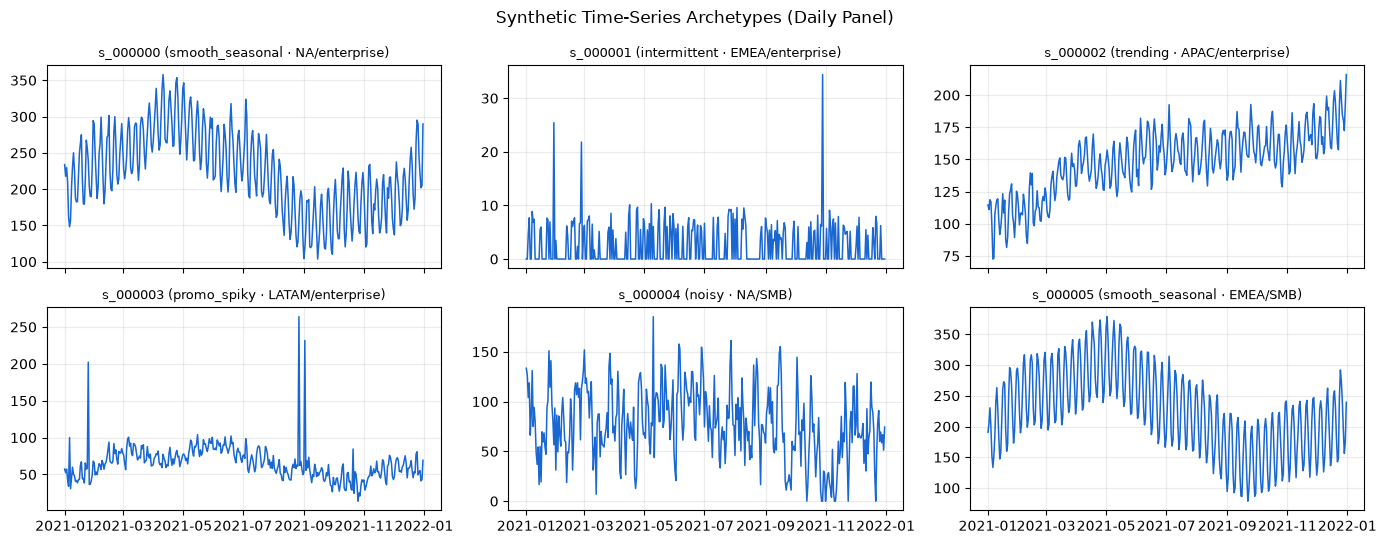

In [4]:
import matplotlib.pyplot as plt
from scale_forecasting.playground import sample_data

panel = sample_data(n_series=6, history=365, freq="D", with_exog=True, with_hierarchy=True)
print(f"Panel shape: {panel.shape} | Unique series: {panel['ts_id'].nunique()}")
print("Columns:", list(panel.columns))
display(panel.head())

fig, axes = plt.subplots(2, 3, figsize=(14, 5.5), sharex=True)
for ax, (ts_id, g) in zip(axes.flat, panel.groupby("ts_id")):
    archetype = g["archetype"].iloc[0]
    region = g["region"].iloc[0]
    cat = g["category"].iloc[0]
    ax.plot(pd.to_datetime(g["ds"]), g["y"], lw=1.1, color="#1967D2")
    ax.set_title(f"{ts_id} ({archetype} · {region}/{cat})", fontsize=9.5)
    ax.grid(alpha=0.25)
fig.suptitle("Synthetic Time-Series Archetypes (Daily Panel)", fontsize=12)
fig.tight_layout()
plt.show()

## Act 3 · Single-Series Fit, Rolling-Origin Backtest & Conformal Intervals

Let's run a single model (`theta`) on `s_000000` with `backtest=True` (`3` rolling-origin folds of `28` days each). Under the hood, `run_model()` validates the panel with `validate_panel()`, builds a `RunConfig`, and calls `worker.run_cell()`:
1. **Rolling-Origin Backtest (`backtest_cell`):** Fits the model on each fold's training window, predicts the validation horizon, and scores all **21 evaluation metrics**.
2. **Conformal Interval Calibration (`calibration.py`):** Uses out-of-fold signed residuals to calibrate empirical prediction bands (`yhat_lower`, `yhat_upper`) at the nominal `0.80` level.
3. **Visual Inspection (`build_predictions_frame` + `plot_forecasts_frame`):** Overlays historical actuals, out-of-fold backtest predictions, and the future forecast fan chart.

model      : theta
series     : s_000000  (365 obs)
engine     : spark
status     : ok
forecast   : 28 steps
horizon    : 2022-01-01 → 2022-01-28
metrics    : mae=20.992, rmse=27.562, mse=868.198, mape=0.100, smape=0.109, wape=0.108, mase=0.806, rmsse=0.901, bias=-19.168, coverage=0.988, pinball=13.928, mase_seasonal=1.539, maape=0.099, interval_score=278.556, interval_width=278.461, ope=0.098, rmsle=0.138, msse=0.925, msis=20.459, r2=0.372, cv=0.141


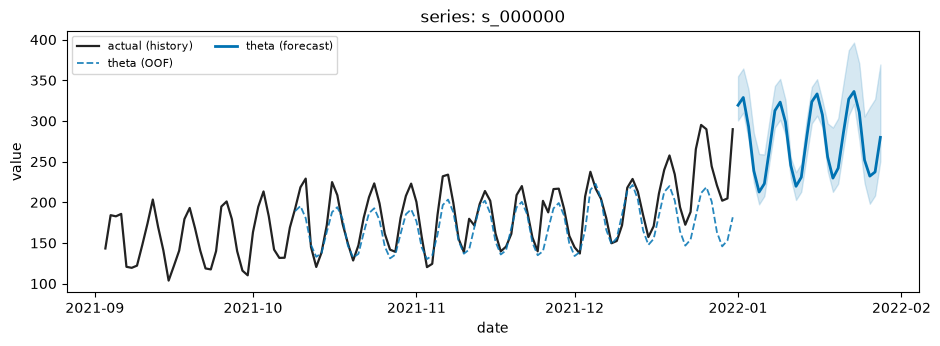

,ts_id,model_type,segment,ds,y_true,yhat,yhat_lower,yhat_upper,trend_baseline,level_shift,seasonal_effect,covariate_effect,oof_residual,interval_width,cov_promo_flag,cov_price_index,cov_temperature
383,s_000000,theta,forecast,2022-01-19,NaN,229.731851,212.769441,291.902236,283.046109,-75.702006,-42.500641,4.050408,NaN,79.132795,4.437616,0.008648,-0.395856
384,s_000000,theta,forecast,2022-01-20,NaN,241.982758,222.942752,303.211413,283.473299,-75.702006,-34.427255,4.050408,NaN,80.268661,4.437616,0.008648,-0.395856
385,s_000000,theta,forecast,2022-01-21,NaN,285.889898,265.627669,345.896330,283.913297,-75.702006,1.917987,4.050408,NaN,80.268661,4.437616,0.008648,-0.395856
386,s_000000,theta,forecast,2022-01-22,NaN,326.950255,306.688027,386.956688,283.356285,-75.702006,33.684912,4.050408,NaN,80.268661,4.437616,0.008648,-0.395856
387,s_000000,theta,forecast,2022-01-23,NaN,336.288757,320.952732,396.376869,283.710607,-75.702006,41.596991,4.050408,NaN,75.424137,4.437616,0.008648,-0.395856
388,s_000000,theta,forecast,2022-01-24,NaN,310.767908,277.204897,370.856020,283.045334,-75.702006,20.950685,4.050408,NaN,93.651123,4.437616,0.008648,-0.395856
389,s_000000,theta,forecast,2022-01-25,NaN,251.882568,223.912853,305.535526,282.183880,-75.702006,-21.222680,4.050408,NaN,81.622673,4.437616,0.008648,-0.395856
390,s_000000,theta,forecast,2022-01-26,NaN,232.212102,198.194206,316.815728,274.722817,-75.702006,-42.500641,4.050408,NaN,118.621521,4.437616,0.008648,-0.395856
391,s_000000,theta,forecast,2022-01-27,NaN,237.325853,208.331255,326.952776,262.409629,-75.702006,-34.427255,4.050408,NaN,118.621521,4.437616,0.008648,-0.395856
392,s_000000,theta,forecast,2022-01-28,NaN,279.859717,250.865118,369.486640,250.320060,-75.702006,1.917987,4.050408,NaN,118.621521,4.437616,0.008648,-0.395856


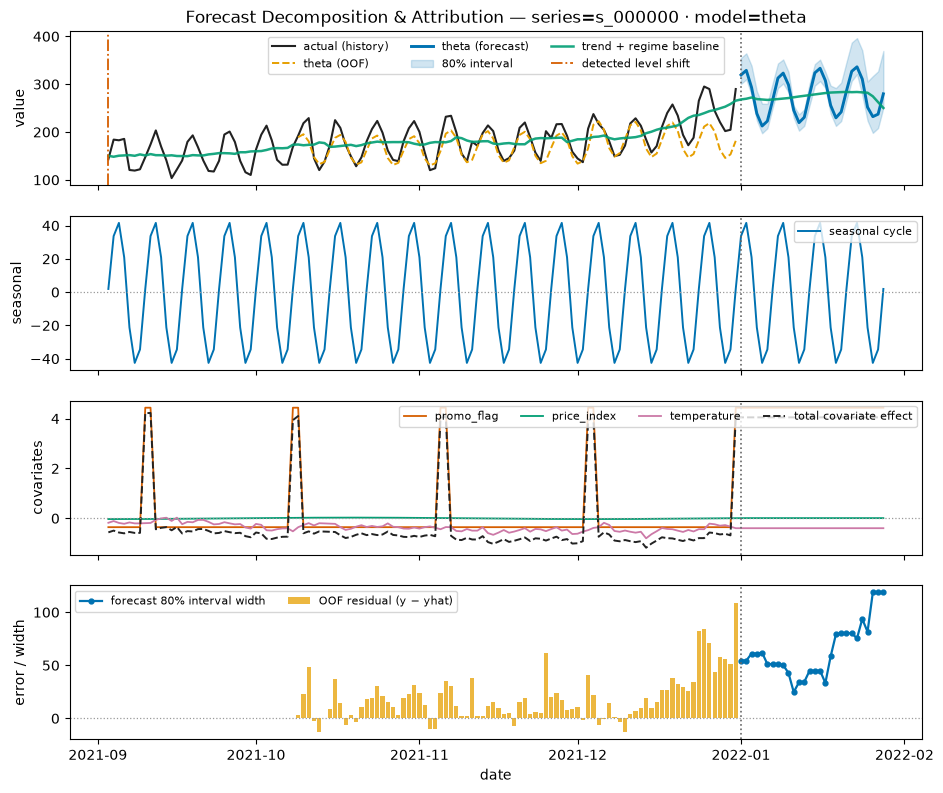

In [5]:
from scale_forecasting import (
    build_predictions_frame,
    explain_forecast_frame,
    plot_forecast_explanation,
    plot_forecasts_frame,
)
from scale_forecasting.playground import run_model, summarize

run = run_model("theta", data=panel, ts_id="s_000000", horizon=28, backtest=True)
print(summarize(run))

# Convert the single-cell result into the standard long-format predictions frame used by the SDK
pred_rows = (
    run.result.predictions.rename(columns={"ds": "forecast_date"})
    .assign(ts_id=run.result.ts_id, model_type=run.result.model_type)
    .to_dict("records")
)
oof_rows = (
    run.result.oof.rename(columns={"ds": "forecast_date"})
    .assign(ts_id=run.result.ts_id, model_type=run.result.model_type)
    .to_dict("records")
)
hist_rows = run.series[["ts_id", "ds", "y"]].to_dict("records")

pf = build_predictions_frame(pred_rows, oof_rows=oof_rows, history_rows=hist_rows)
fig = plot_forecasts_frame(pf, history_tail=120)
plt.show()

# 4-panel Forecast Explainability & Structural Attribution (Trend + Regime Shift + Seasonality + Exog + Uncertainty)
exog_df = run.series[["ts_id", "ds", "promo_flag", "price_index", "temperature"]]
exp_df = explain_forecast_frame(pf, covariate_df=exog_df, seasonal_period=7)
display(exp_df.tail(10))
plot_forecast_explanation(exp_df, history_tail=120)
plt.show()

## Act 4 · Training Regimes Offline: `local` vs. `global` vs. `hybrid`

`scale-forecasting` supports three distinct training regimes via `model_params[model]['training_mode']`:
- **`local`:** Fits an independent model instance per `(ts_id, model)` cell (`worker.run_cell`).
- **`global`:** Pools all series in the panel into a single cross-series neural network (`worker.run_panel` with `training_mode='global'`), supported by all 5 `deep_learning` architectures (`neuralprophet`, `tide`, `tsmixer`, `patchtst`, `tft`).
- **`hybrid` (Local + Global Shared-Plus-Series Network):** Combines shared cross-series trend/seasonality representations with per-series local parameters (`worker.run_panel` with `training_mode='hybrid'`, supported by `neuralprophet`).

In [6]:
from scale_forecasting.config import RunConfig
from scale_forecasting.worker import run_cell, run_panel

regime_cfg = RunConfig.model_validate({
    "run_name": "playground-regimes",
    "data": {"source_table": "playground", "freq": "D", "horizon": 14},
    "models": ["neuralprophet"],
    "model_params": {"neuralprophet": {"epochs": 15}},
    "backtest": {"enabled": True, "n_folds": 2, "horizon": 14, "step": 14},
})

# 1. Local per-series fit on all 6 series
local_results = [
    run_cell(g.reset_index(drop=True), "neuralprophet", regime_cfg)
    for _, g in panel.groupby("ts_id", sort=True)
]
# 2. Global pooled fit across all 6 series simultaneously
global_results = run_panel(panel, "neuralprophet", regime_cfg, params={"training_mode": "global", "epochs": 15})
# 3. Hybrid local+global fit across all 6 series
hybrid_results = run_panel(panel, "neuralprophet", regime_cfg, params={"training_mode": "hybrid", "epochs": 15})

comparison_rows = []
for mode_label, res_list in [("local", local_results), ("global", global_results), ("hybrid", hybrid_results)]:
    for r in res_list:
        comparison_rows.append({
            "training_mode": mode_label,
            "ts_id": r.ts_id,
            "wape": r.metrics.get("wape"),
            "mae": r.metrics.get("mae"),
            "mase": r.metrics.get("mase"),
            "coverage": r.metrics.get("coverage"),
        })
regime_df = pd.DataFrame(comparison_rows)
display(regime_df.groupby("training_mode")[["wape", "mae", "mase", "coverage"]].mean().reset_index())

,training_mode,wape,mae,mase,coverage
0,global,0.504413,23.290220,1.680554,0.738095
1,hybrid,0.386277,22.470124,1.126287,0.672619
2,local,0.406539,22.152474,1.110474,0.964286


## Act 5 · Hierarchical Aggregation & All 7 FPP3 Reconciliation Methods Offline

When `hierarchy.enabled=True`, `build_hierarchy()` rolls the bottom-level series (`ts_id`) up every level of the tree (`__total__` $\rightarrow$ `region` $\rightarrow$ `region/category` $\rightarrow$ `ts_id`) and constructs the summing matrix $S$. After base models forecast every node independently, `reconcile_forecasts()` projects the incoherent base forecasts $\hat{y}$ onto the coherent subspace $\tilde{y} = S G \hat{y}$ using any of the **7 FPP3 reconciliation estimators**:
- `bottom_up`, `top_down`, `middle_out`, `ols`, `wls_struct`, `wls_var`, `mint_shrink`

Hierarchy nodes: 17 total (6 bottom + 11 aggregate) | S shape: (17, 6)


,method,max_coherence_error,coherent
0,bottom_up,1.136868e-13,True
1,top_down,1.136868e-13,True
2,middle_out,1.136868e-13,True
3,ols,3.410605e-13,True
4,wls_struct,3.410605e-13,True
5,wls_var,1.136868e-13,True
6,mint_shrink,2.273737e-13,True


,model_type,level,n_series,n_points,mean_yhat,sum_yhat,max_coherence_residual
0,theta_mint_shrink,total,1,14,830.535936,11627.503106,991.067465
1,theta_mint_shrink,aggregate,6,84,138.422656,11627.503106,991.067465
2,theta_mint_shrink,bottom,10,140,166.107187,23255.006212,991.067465


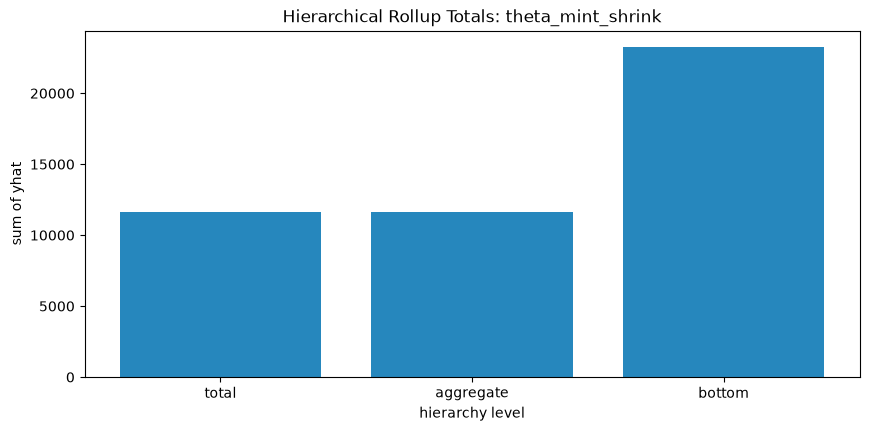

In [7]:
from scale_forecasting import (
    build_hierarchy,
    build_hierarchy_frame,
    plot_hierarchy_frame,
    reconcile_forecasts,
    verify_coherence,
)

hier_cfg = RunConfig.model_validate({
    "run_name": "playground-hierarchy",
    "data": {"source_table": "playground", "freq": "D", "horizon": 14},
    "models": ["theta"],
    "hierarchy": {
        "enabled": True,
        "levels": [["region"], ["region", "category"]],
        "reconciliation_methods": ["bottom_up", "top_down", "middle_out", "ols", "wls_struct", "wls_var", "mint_shrink"],
        "middle_level": ["region"],
    },
    "backtest": {"enabled": True, "n_folds": 2, "horizon": 14, "step": 14},
})
full_panel, spec = build_hierarchy(panel, hier_cfg)
print(f"Hierarchy nodes: {spec.n_nodes} total ({spec.n_bottom} bottom + {spec.n_aggregated} aggregate) | S shape: {spec.summing_matrix.shape}")

# Fit a fast statistical model ('theta') on every node in the hierarchy
node_cells = [
    run_cell(g.reset_index(drop=True), "theta", hier_cfg)
    for _, g in full_panel.groupby("ts_id", sort=True)
]
base_preds = pd.concat([
    c.predictions.rename(columns={"ds": "forecast_date"}).assign(ts_id=c.ts_id, model_type=c.model_type)
    for c in node_cells
], ignore_index=True)
base_oof = pd.concat([
    c.oof.rename(columns={"ds": "forecast_date"}).assign(ts_id=c.ts_id, model_type=c.model_type)
    for c in node_cells if c.oof is not None
], ignore_index=True)

# Compare all 7 FPP3 reconciliation methods and verify exact mathematical coherence
methods = ["bottom_up", "top_down", "middle_out", "ols", "wls_struct", "wls_var", "mint_shrink"]
coherence_rows = []
for m in methods:
    rec_df = reconcile_forecasts(
        base_preds, spec, m,
        history_df=full_panel, oof_df=base_oof,
        middle_level=["region"] if m == "middle_out" else None,
    )
    max_discrepancy = verify_coherence(rec_df, spec)
    coherence_rows.append({"method": m, "max_coherence_error": max_discrepancy, "coherent": max_discrepancy < 1e-6})

display(pd.DataFrame(coherence_rows))

# Visualize node rollups across hierarchy levels for mint_shrink
mint_df = reconcile_forecasts(base_preds, spec, "mint_shrink", history_df=full_panel, oof_df=base_oof)
hf = build_hierarchy_frame(mint_df.to_dict("records"))
display(hf)
fig = plot_hierarchy_frame(hf)
plt.show()

## Act 6 · Multi-Model Bake-Off, Stacked Ensembles & `Forecaster.explain()`

`bakeoff()` runs multiple candidate models head-to-head on a single series and combines them using both:
- **Calculated Ensembling (`inverse_error`):** Weights each model inversely proportional to its validation loss.
- **Learned Stacking (`nnls`):** Fits non-negative least squares weights across out-of-fold backtest predictions.

Finally, we preview `Forecaster.explain(validate_data=False)` on a multi-family `RunConfig` to see how the SDK summarizes per-family runtime routing, hardware shapes, covariates, HPO, and ensembling before any cloud job is launched.

In [8]:
from scale_forecasting import Forecaster
from scale_forecasting.playground import bakeoff

bo = bakeoff(data=panel, ts_id="s_000000", models=["theta", "holtwinters", "stl_bagging", "xgboost"], horizon=28, n_folds=2)
display(bo.leaderboard[["model", "kind", "status", "wape", "mae", "rmse", "mase", "coverage", "interval_score"]])

# Preview Forecaster.explain() on a 4-family production RunConfig (no cloud needed with validate_data=False)
preview_cfg = RunConfig.model_validate({
    "run_name": "enterprise-preview",
    "python_runtime": "spark",
    "data": {"source_table": "source_series_iceberg", "horizon": 28, "series_limit": 500},
    "models": ["theta", "autoets", "lightgbm", "xgboost", "neuralprophet", "arima_plus", "timesfm"],
    "compute": {
        "families": {
            "deep_learning": {"runtime": "ray", "hardware": "gpu", "gpu_type": "L4", "min_workers": 1, "max_workers": 2},
        },
    },
    "features": {"holidays": ["US"], "future_covariates": ["promo_flag"]},
    "backtest": {"enabled": True, "n_folds": 2, "horizon": 28, "step": 28},
    "ensemble": {"enabled": True, "strategies": ["inverse_error", "nnls", "ridge"]},
})
plan_df = Forecaster(preview_cfg).explain(validate_data=False)
display(plan_df)

,model,kind,status,wape,mae,rmse,mase,coverage,interval_score
0,holtwinters,base,ok,0.098104,19.716912,26.835893,0.755259,0.500000,119.839309
1,ensemble_inverse_error,ensemble,ok,0.106172,21.544101,29.359942,0.825276,NaN,NaN
2,xgboost,base,ok,0.112572,22.841938,31.155169,0.874991,0.053571,224.679197
3,stl_bagging,base,ok,0.113094,23.052544,30.493329,0.883072,0.375000,178.833948
4,theta,base,ok,0.115866,23.499630,31.542060,0.900184,0.982143,283.769321
5,ensemble_nnls,ensemble,ok,0.115866,23.499630,31.542060,0.900184,NaN,NaN


,run_id,family,job_key,runtime,machine_type,workers,hardware,gpu_type,models,training_modes,n_series,n_folds,expected_cells,covariates,depends_on
0,enterprise-preview-8c175c84010f,statistical,sf-enterprise-preview-8c175c84010f-statistical-a1,spark,None,NaN,cpu,None,"theta, autoets","theta:local, autoets:local",500,2,1000,future(1),
1,enterprise-preview-8c175c84010f,ml,sf-enterprise-preview-8c175c84010f-ml-a1,spark,None,NaN,cpu,None,"lightgbm, xgboost","lightgbm:local, xgboost:local",500,2,1000,future(1),
2,enterprise-preview-8c175c84010f,deep_learning,sf-enterprise-preview-8c175c84010f-deep_learni...,ray,None,NaN,gpu,L4,neuralprophet,neuralprophet:local,500,2,500,future(1),
3,enterprise-preview-8c175c84010f,native,sf-enterprise-preview-8c175c84010f-native-a1,bigquery,sql,1.0,sql,None,"arima_plus, timesfm","arima_plus:local, timesfm:local",500,2,1000,future(1),
4,enterprise-preview-8c175c84010f,ensemble,sf-enterprise-preview-8c175c84010f-ensemble-a1,bigquery,sql,1.0,sql,None,"ensemble_inverse_error, ensemble_nnls, ensembl...",barrier,500,2,1500,future(1),sf-enterprise-preview-8c175c84010f-statistical...
